# Excercises week 4

### Problem 4.1
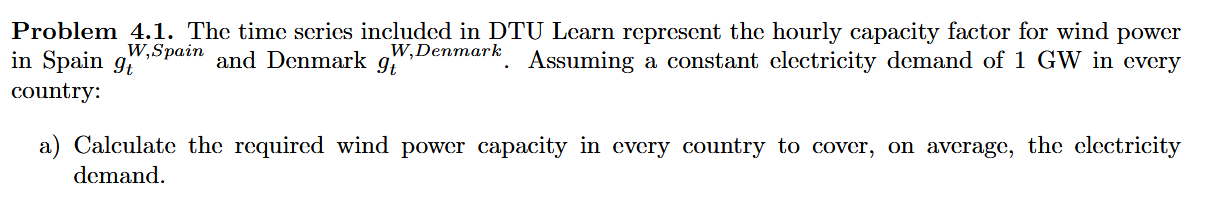

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load wind capacirt factors
wind = pd.read_csv("onshore_wind.csv", sep = ";")

# Wind capacity factor Denmark
wind_dk = wind[["DNK"]]
wind_esp = wind[["ESP"]]

demand = 1 # GW

wind_cap_dk = demand / wind_dk.mean()
print("Installed wind capacity in Denmark: ", wind_cap_dk, " GW")

wind_cap_esp = demand / wind_esp.mean()
print("Installed wind capacity in Denmark: ", wind_cap_esp, " GW")


Installed wind capacity in Denmark:  DNK    3.632738
dtype: float64  GW
Installed wind capacity in Denmark:  ESP    4.299325
dtype: float64  GW


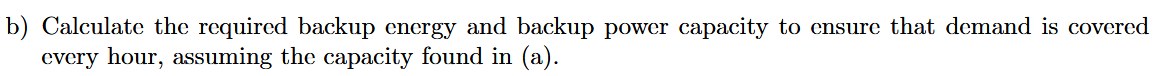

In [2]:
# Back capacity to cover demand each hour
wind_back_dk = []
time = range(len(wind_dk))
for t in time:
    wind_back_dk.append(demand - wind_dk.iloc[t].values[0] * wind_cap_dk.values[0])

back_up_dk = max(wind_back_dk)
print("Back up capacity needed in Denmark: ", back_up_dk, " GW")

wind_back_esp = []
for t in time:
    wind_back_esp.append(demand - wind_esp.iloc[t].values[0] * wind_cap_esp.values[0])
back_up_esp = max(wind_back_esp)
print("Back up capacity needed in Spain: ", back_up_esp, " GW")

Back up capacity needed in Denmark:  0.9923385545773723  GW
Back up capacity needed in Spain:  0.9003975309781712  GW


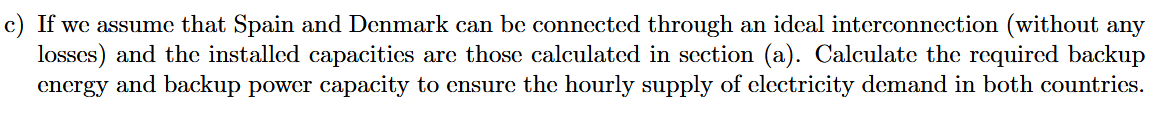

In [3]:
tot_demand = 2 # GW

tot_back = []
for t in time:
    tot_back.append(tot_demand - (wind_dk.iloc[t].values[0] * wind_cap_dk.values[0] + wind_esp.iloc[t].values[0] * wind_cap_esp.values[0]))
back_up_tot = max(tot_back)
print("Back up capacity needed in total: ", back_up_tot, " GW")

Back up capacity needed in total:  1.7241951029263909  GW


### Problem 4.2

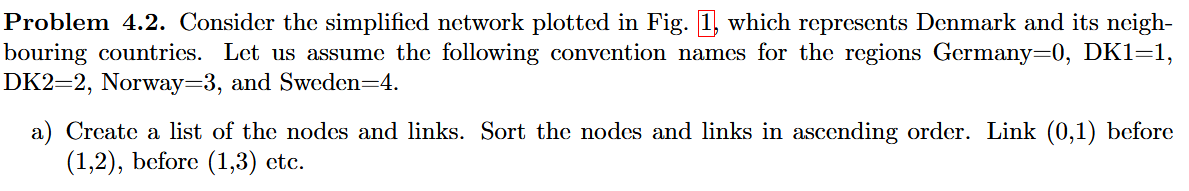

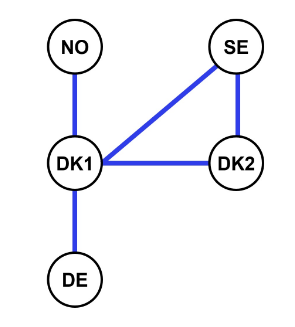

In [4]:
nodes = ["0", "1", "2", "3", "4"]
links = [("0", "1"), ("1", "2"), ("1", "3"), ("1", "4"), ("2", "4")]


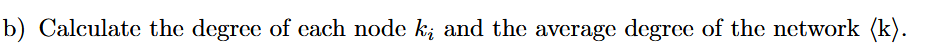

In [6]:
# Calculate the degree of each node
degree = {node: 0 for node in nodes}
degree["0"] = 1
degree["1"] = 4
degree["2"] = 2
degree["3"] = 1
degree["4"] = 2



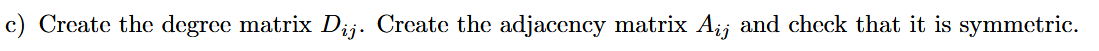

In [11]:
# Use only the first 4 nodes
nodes_4x4 = nodes[:4]

# create the degree matrix
degree_matrix = pd.DataFrame(0, index=nodes_4x4, columns=nodes_4x4)
for node in nodes_4x4:
    degree_matrix.loc[node, node] = degree[node]
print("Degree matrix:")
print(degree_matrix)

# create the adjacency matrix
adjacency_matrix = pd.DataFrame(0, index=nodes_4x4, columns=nodes_4x4)
for link in links:
    if link[0] in nodes_4x4 and link[1] in nodes_4x4:
        adjacency_matrix.loc[link[0], link[1]] = 1
        adjacency_matrix.loc[link[1], link[0]] = 1
print("Adjacency matrix:")
print(adjacency_matrix)

Degree matrix:
   0  1  2  3
0  1  0  0  0
1  0  4  0  0
2  0  0  2  0
3  0  0  0  1
Adjacency matrix:
   0  1  2  3
0  0  1  0  0
1  1  0  1  1
2  0  1  0  0
3  0  1  0  0


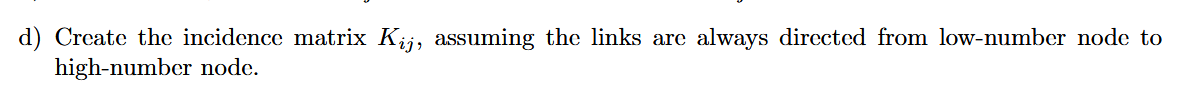